In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from few.waveform import GenerateEMRIWaveform
from few.utils.constants import MTSUN_SI
from few.utils.utility import get_p_at_t
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.fdutils import GetFDWaveformFromFD, GetFDWaveformFromTD
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux, KerrEccEqFlux_nex

from scipy.interpolate import CubicSpline
from few import get_file_manager

# produce sensitivity function
traj_module = EMRIInspiral(func=KerrEccEqFlux_nex)

# import ASD
data = np.loadtxt(get_file_manager().get_file("LPA.txt"), skiprows=1)
data[:, 1] = data[:, 1] ** 2
# define PSD function
get_sensitivity = CubicSpline(*data.T)

In [43]:
td_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux_nex",
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True,
)

td_gen_few = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux",
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True,
)

In [93]:
# define the injection parameters
m1 = 1e6  # central object mass (solar masses)
a = 1-10**(-10)    # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform
m2 = 10.0  # secondary object mass (solar masses)
p0 = 10.0  # initial dimensionless semi-latus rectum 
e0 = 0.2  # eccentricity

x0 = 1.0         # initial cos(inclination) - will be ignored in Schwarzschild waveform
qK = np.pi / 3   # polar spin angle
phiK = np.pi / 3 # azimuthal viewing angle
qS = np.pi / 3   # polar sky angle
phiS = np.pi / 3 # azimuthal viewing angle
dist = 1.0       # luminosity distance (Gpc)

# initial phases
Phi_phi0 = np.pi / 3
Phi_theta0 = 0.0
Phi_r0 = np.pi / 3

Tobs = 20*1/365  # observation time (years), if the inspiral is shorter, the it will be zero padded
dt = 1.0    # time interval (seconds)
mode_selection_threshold = 1e-4  # relative threshold for mode inclusion: only modes making a relative contribution to
            # the total power above this threshold will be included in the waveform.



waveform_kwargs = {
    "T": Tobs,
    "dt": dt,
    "mode_selection_threshold": mode_selection_threshold,
}

# get the initial p0 required for an inspiral of length Tobs, given the fixed values of the other parameters

p0 = get_p_at_t(
    traj_module,
    Tobs * 0.999,
    [m1, m2, a, e0, 1.0],       # list of trajectory arguments, with p removed
    index_of_p=3,               # index where to insert the new p values in the above traj_args list when traj_module is called 
    index_of_a=2,               # index of a in the list of trajectory arguments when calling traj_module
    index_of_e=4,               # etc...
    index_of_x=5,
    traj_kwargs={},
    xtol=2e-12,                 # absolute tolerance for the brentq root finder
    rtol=8.881784197001252e-16, # relative tolerance for the brentq root finder
    bounds=None,
)
print("New p0: ", p0)



emri_injection_params = [
    m1,
    m2,
    a,
    p0,
    e0,
    x0,
    dist,
    qS,
    phiS,
    qK,
    phiK,
    Phi_phi0,
    Phi_theta0,
    Phi_r0,
]

New p0:  2.3553411061030602


In [94]:
start = time.time()
data_channels_td = td_gen(*emri_injection_params, **waveform_kwargs) # Returns 2 arrays containing the plus and cross polarizations
end = time.time()
print("Time taken to generate the NEX TD signal: ", end - start, "seconds")

'''
start = time.time()
data_channels_td_few = td_gen_few(*emri_injection_params, **waveform_kwargs) 
end = time.time()
print("Time taken to generate the FEW TD signal: ", end - start, "seconds")
'''

Time taken to generate the NEX TD signal:  4.598252058029175 seconds


'\nstart = time.time()\ndata_channels_td_few = td_gen_few(*emri_injection_params, **waveform_kwargs) \nend = time.time()\nprint("Time taken to generate the FEW TD signal: ", end - start, "seconds")\n'

Text(0.5, 1.0, 'a=0.9999999999, $p_0$ = 2.3553, $e_0$ = 0.2')

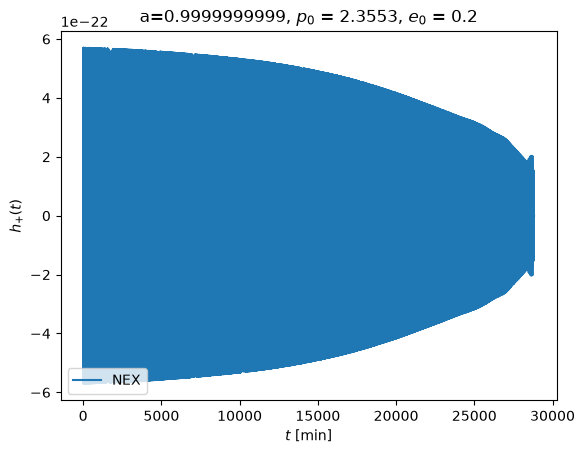

In [95]:

plt.figure()
time_array = np.arange(0, len(data_channels_td[0])) * dt
plt.plot(time_array/60, data_channels_td[0].real, label="NEX")
#plt.plot(time_array/60, data_channels_td_few[0].real,"--", label="KerrEccEq")

plt.ylabel(r"$h_{+}(t)$")
plt.xlabel(r"$t$ [min]")

#plt.xlim(0,30)
plt.legend(loc = 'lower left')
plt.title(rf"a={a}, $p_0$ = {round(p0,4)}, $e_0$ = {e0}")

#plt.savefig(f"snapshot_comparison_a={a}_e0={e0}.png", dpi=300, bbox_inches="tight")

Text(0.5, 0.98, 'a=0.99, $p_0$ = 1.6595, $e_0$ = 0.2')

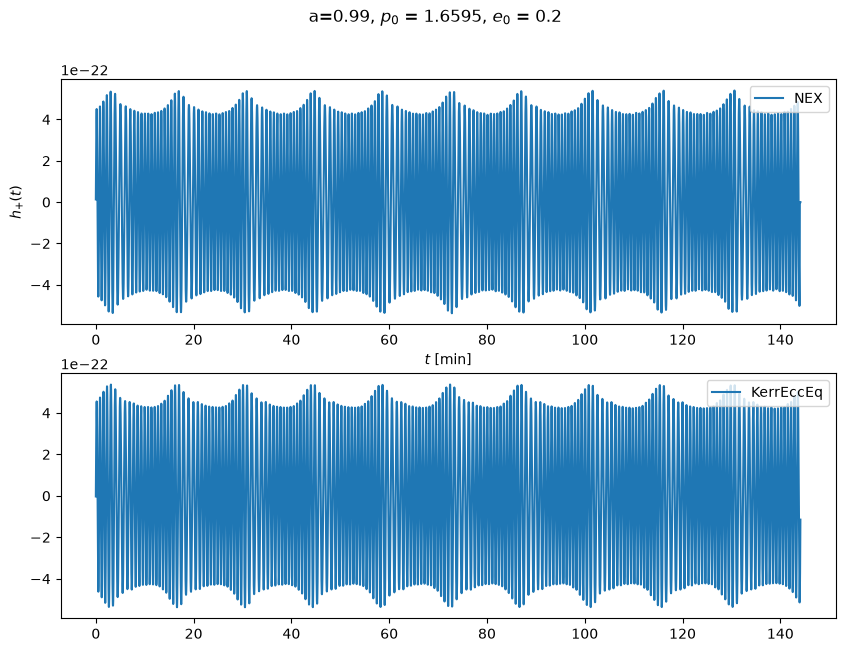

In [77]:
fig, axs = plt.subplots(2,1,figsize = (10,7))

time_array = np.arange(0, len(data_channels_td[0])) * dt
axs[0].plot(time_array/60, data_channels_td[0].real, label="NEX")
axs[1].plot(time_array/60, data_channels_td_few[0].real,"-", label="KerrEccEq")

axs[0].set_ylabel(r"$h_{+}(t)$")
axs[0].set_xlabel(r"$t$ [min]")

#plt.xlim(0,30)
axs[0].legend()
axs[1].legend()
plt.suptitle(rf"a={a}, $p_0$ = {round(p0,4)}, $e_0$ = {e0}")

Text(0.5, 0, '$t$ (hours)')

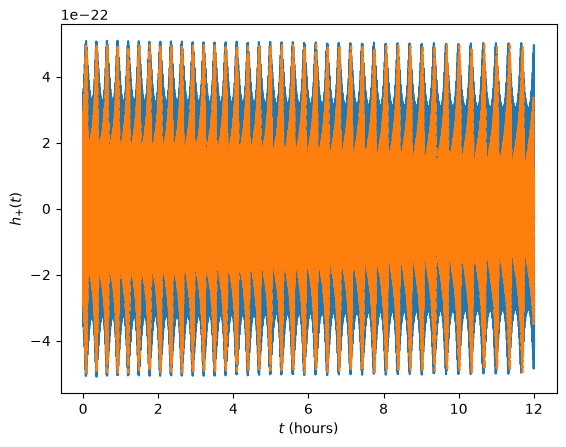

In [68]:
plt.figure()

time_increments = [1 , 60 , (3600), (24*3600), 24*2600*365 ]    
time_names = ["seconds","minutes","hours","days", "years"]
i=2

time_array_few = np.arange(0, len(data_channels_td_few[0])) * dt
plt.plot(time_array_few/time_increments[i], data_channels_td_few[0].real, label="TD waveform")

time_array = np.arange(0, len(data_channels_td[0])) * dt
plt.plot(time_array/time_increments[i], data_channels_td[0].real, "--",label="TD waveform")



plt.ylabel(r"$h_{+}(t)$")
plt.xlabel(rf"$t$ ({time_names[i]})")

#plt.xlim(time_array_few[-1]-250000,time_array_few[-1])

In [17]:
3600*24/60

1440.0

In [149]:
60*24

1440

In [33]:
td_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux_nex",
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True,
)

def wf(n,e0,T):


        # define the injection parameters
    m1 = 1e6  # central object mass (solar masses)
    a = 1-10**(-n)    # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform
    m2 = 10.0  # secondary object mass (solar masses)
    p0 = 10.0  # initial dimensionless semi-latus rectum 
    e0 = e0  # eccentricity

    x0 = 1.0         # initial cos(inclination) - will be ignored in Schwarzschild waveform
    qK = np.pi / 3   # polar spin angle
    phiK = np.pi / 3 # azimuthal viewing angle
    qS = np.pi / 3   # polar sky angle
    phiS = np.pi / 3 # azimuthal viewing angle
    dist = 1.0       # luminosity distance (Gpc)

    # initial phases
    Phi_phi0 = np.pi / 3
    Phi_theta0 = 0.0
    Phi_r0 = np.pi / 3

    Tobs = T  # observation time (years), if the inspiral is shorter, the it will be zero padded
    dt = 10 #round(T/1e8)    # time interval (seconds)
    mode_selection_threshold = 1e-4  # relative threshold for mode inclusion: only modes making a relative contribution to
                # the total power above this threshold will be included in the waveform.



    waveform_kwargs = {
        "T": Tobs,
        "dt": dt,
        "mode_selection_threshold": mode_selection_threshold,
    }

    # get the initial p0 required for an inspiral of length Tobs, given the fixed values of the other parameters

    p0 = get_p_at_t(
        traj_module,
        Tobs*0.99999,
        [m1, m2, a, e0, 1.0],       # list of trajectory arguments, with p removed
        index_of_p=3,               # index where to insert the new p values in the above traj_args list when traj_module is called 
        index_of_a=2,               # index of a in the list of trajectory arguments when calling traj_module
        index_of_e=4,               # etc...
        index_of_x=5,
        traj_kwargs={},
        xtol=2e-12,                 # absolute tolerance for the brentq root finder
        rtol=8.881784197001252e-16, # relative tolerance for the brentq root finder
        bounds=None,
    )
    print("New p0: ", p0)



    emri_injection_params = [
        m1,
        m2,
        a,
        p0,
        e0,
        x0,
        dist,
        qS,
        phiS,
        qK,
        phiK,
        Phi_phi0,
        Phi_theta0,
        Phi_r0,
    ]

    data_channels_td = td_gen(*emri_injection_params, **waveform_kwargs) 
    time_array = np.arange(0, len(data_channels_td[0])) * dt

    return time_array, data_channels_td

In [29]:
e_vals = [0,0.2,0.4]
h=24*365           #numbver of hours
time = (1/365)*(h/24)
n=9

t1,wf1 = wf(n,e_vals[0],time)
t2,wf2 = wf(n,e_vals[1],time)
t3,wf3 = wf(n,e_vals[2],time)

New p0:  6.763404291804852
New p0:  6.753278524571227
New p0:  6.703049217422079


In [25]:
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 12,
})

Text(0.5, 0.98, 'Final year of inspiral for $a=1-10^{-9}$')

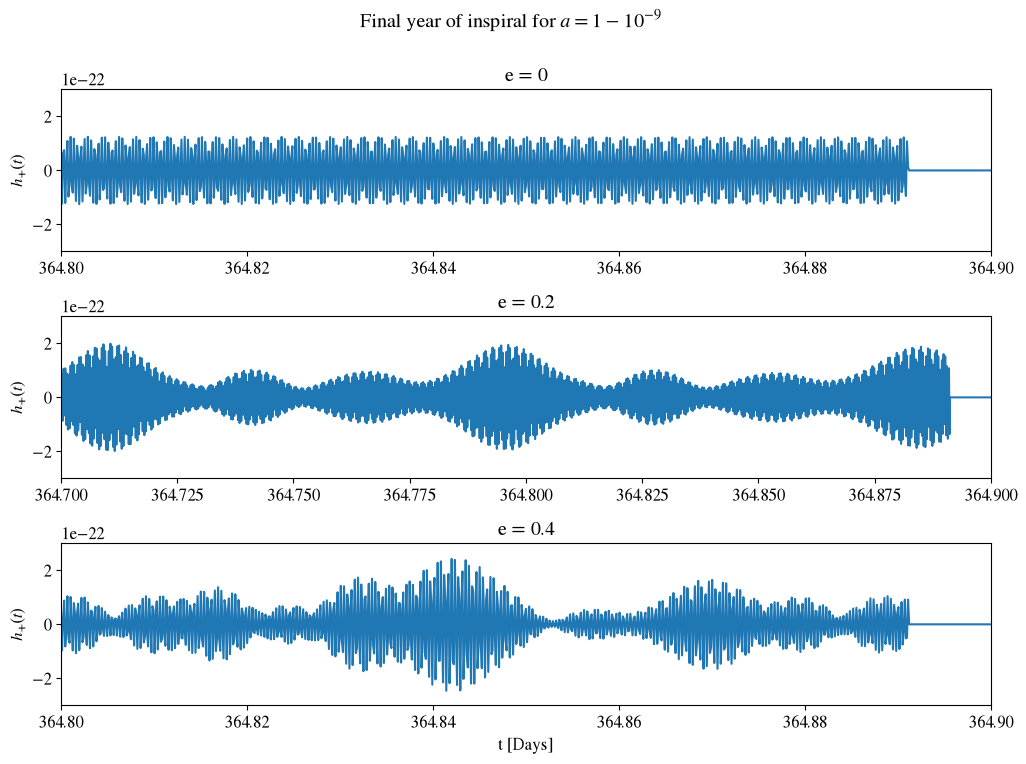

In [48]:
time_increments = [1 , 60 , (3600), (24*3600), 24*2600*365 ]    
time_names = ["seconds","minutes","hours","days", "years"]
i=2

fig,axs = plt.subplots(3,1,figsize = (12,8))

tdiv = 3600*24
axs[0].plot(t1/(tdiv),wf1[0])
axs[1].plot(t2/(tdiv),wf2[0])
axs[2].plot(t3/(tdiv),wf3[0])

axs[0].set_title(f"e = {e_vals[0]}")
axs[1].set_title(f"e = {e_vals[1]}")
axs[2].set_title(f"e = {e_vals[2]}")

fig.subplots_adjust(
    wspace=0.4,  # horizontal space between subplots
    hspace=0.4   # vertical space between subplots
)

axs[2].set_xlabel("t [Days]")
axs[0].set_ylabel(r"$h_{+}(t)$")
axs[1].set_ylabel(r"$h_{+}(t)$")
axs[2].set_ylabel(r"$h_{+}(t)$")

axs[0].set_xlim(364.8,364.9)
axs[1].set_xlim(364.7,364.9)
axs[2].set_xlim(364.8,364.9)

axs[0].set_ylim(-3e-22,3e-22)
axs[1].set_ylim(-3e-22,3e-22)
axs[2].set_ylim(-3e-22,3e-22)

plt.suptitle(rf"Final year of inspiral for $a=1-10^{{-{n}}}$")

#fig.savefig(f"WF_n=9_T=1hour.png", dpi=300, bbox_inches="tight")

In [41]:
60/(365*24*3600)

1.902587519025875e-06